# Notebook 3 — Exploratory Data Analysis & Statistical Testing

**Purpose:** Direct category-level statistical analysis of book-level taxonomy proportions.

Outputs are saved to:

`results/stage10_correlation_analysis/notebook3_eda/`

## Purpose and Analytical Shift

Earlier stages of this pipeline focused on constructing composite indices that aggregated multiple thematic signals into single summary measures (e.g., intimacy or conflict indices).

In this notebook, we intentionally **move away from index construction** and instead focus on **direct statistical exploration of existing theory-driven tags and labels produced by the model**.

The goal is to:

- Preserve interpretability of individual taxonomy categories
- Avoid introducing researcher-defined weighting schemes
- Examine how category proportions relate empirically to outcome labels (e.g., rating class)

All analyses operate on **already computed category proportions** and **observed labels**, without generating new composite features.

## Data Used in This Analysis

This notebook relies on two core tables produced in earlier stages:

1. **Book-level category proportions**
   - Each row represents a book–category pairing
   - Category proportions reflect the share of sentences assigned to each taxonomy category
   - Outcome labels (e.g., rating class) are attached at the book level

2. **Topic lookup table**
   - Maps individual model topics to:
     - Taxonomy main categories and groups
     - Radway narrative phases
     - Noise indicators and confidence flags

The topic lookup table is used only for **interpretation and grouping**, not for statistical aggregation.

## Analytical Strategy

Instead of aggregating categories into indices, we pursue three complementary analyses:

1. **Category-level comparisons**
   - Do individual taxonomy categories differ between rating classes?

2. **Group-level comparisons**
   - Do higher-level taxonomy groups (e.g., Sexuality, Relationship Trajectory) show systematic shifts?

3. **Correlation structure**
   - Which categories tend to co-occur within books?
   - Are there distinct thematic clusters?

All statistical tests are non-parametric and include correction for multiple comparisons.

In [1]:
from __future__ import annotations

import os
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def safe_project_root() -> Path:
    """
    Resolve project root robustly by looking for a marker directory/files.
    Adjust markers if your repo layout changes.
    """
    candidates = [Path.cwd()] + list(Path.cwd().parents)
    markers = ["models", "results", "data", "src"]
    for c in candidates:
        if all((c / m).exists() for m in markers):
            return c
    # fallback: assume two levels up from notebooks folder
    return Path.cwd().parents[2]

PROJECT_ROOT = safe_project_root()

# Keep consistent with your NB1/NB2 conventions
EDA_DIR_NB1 = PROJECT_ROOT / "results" / "stage10_correlation_analysis" / "taxonomy_radway_eda"
NB2_DIR     = PROJECT_ROOT / "results" / "stage10_correlation_analysis" / "notebook2_book_features"
NB3_DIR     = PROJECT_ROOT / "results" / "stage10_correlation_analysis" / "notebook3_eda"

FIG_DIR   = NB3_DIR / "figures"
TABLE_DIR = NB3_DIR / "tables"

NB3_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("✓ PROJECT_ROOT:", PROJECT_ROOT)
print("EDA_DIR_NB1:", EDA_DIR_NB1)
print("NB2_DIR   :", NB2_DIR)
print("NB3_DIR   :", NB3_DIR)


✓ PROJECT_ROOT: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor
EDA_DIR_NB1: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/taxonomy_radway_eda
NB2_DIR   : /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook2_book_features
NB3_DIR   : /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda


In [3]:
def file_info(p: Path) -> dict:
    if not p.exists():
        return {"exists": False, "type": "missing", "size": None, "mtime": None}
    st = p.stat()
    return {
        "exists": True,
        "type": "dir" if p.is_dir() else "file",
        "size": None if p.is_dir() else st.st_size,
        "mtime": datetime.fromtimestamp(st.st_mtime).strftime("%Y-%m-%d %H:%M:%S"),
    }

def print_path_report(paths: dict[str, Path]) -> None:
    print("=" * 90)
    print("NOTEBOOK 3 — PATH REPORT")
    print("=" * 90)
    print("CWD:", Path.cwd())
    print("PROJECT_ROOT:", PROJECT_ROOT)
    for k, p in paths.items():
        info = file_info(p)
        print(f"{k:<32}: {p}")
        print(f"  exists={info['exists']}  type={info['type']}  size={info['size']}  mtime={info['mtime']}")
    print("=" * 90)

paths = {
    "NB2 book props (long)": NB2_DIR / "book_taxonomy_main_props_long.parquet",
    "NB2 book props (wide)": NB2_DIR / "book_taxonomy_main_props_wide.parquet",
    "NB2 indices (proxy)"  : NB2_DIR / "indices_book_taxonomy_proxy.parquet",
    "NB1 topic_lookup"     : EDA_DIR_NB1 / "topic_lookup.parquet",
    # optional inputs that might exist in your pipeline:
    "book_topic_probs"     : PROJECT_ROOT / "results" / "stage10_correlation_analysis" / "book_topic_probs.parquet",
    "chapter_topic_probs"  : PROJECT_ROOT / "results" / "stage10_correlation_analysis" / "chapter_topic_probs.parquet",
    "goodreads meta"       : PROJECT_ROOT / "data" / "processed" / "goodreads.csv",
}
print_path_report(paths)


NOTEBOOK 3 — PATH REPORT
CWD: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/notebooks/07_analysis/statistical_analysis
PROJECT_ROOT: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor
NB2 book props (long)           : /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook2_book_features/book_taxonomy_main_props_long.parquet
  exists=True  type=file  size=119917  mtime=2025-12-19 18:08:14
NB2 book props (wide)           : /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook2_book_features/book_taxonomy_main_props_wide.parquet
  exists=True  type=file  size=36716  mtime=2025-12-19 18:08:14
NB2 indices (proxy)             : /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_cor

In [4]:
book_long_path  = paths["NB2 book props (long)"]
book_wide_path  = paths["NB2 book props (wide)"]
indices_path    = paths["NB2 indices (proxy)"]
goodreads_path  = paths["goodreads meta"]

book_long = pd.read_parquet(book_long_path)
book_wide = pd.read_parquet(book_wide_path)
indices   = pd.read_parquet(indices_path)
goodreads = pd.read_csv(goodreads_path)

print("book_long shape:", book_long.shape)
print("book_wide shape:", book_wide.shape)
print("indices   shape:", indices.shape)
print("goodreads shape:", goodreads.shape)

display(book_long.head())
display(book_wide.head())
display(indices.head())
display(goodreads.head())


book_long shape: (2215, 22)
book_wide shape: (92, 29)
indices   shape: (92, 8)
goodreads shape: (97, 14)


,book_id,rating_class,taxonomy_main_id,n_sentences,total_sentences,category_prop,taxonomy_main_name,taxonomy_main_group,unmapped_topic_mass,Author,...,SeriesName,Summary,Genres,Score,RatingsCount,ReviewsCount,Pages,PublishedDate,Popularity_ReadingNow,Popularity_Wishlisted
0,15197.0,good,1.1,4,1327,0.003014,Body Parts & Physical Reactions,Embodied & Sensory Experience,0.0,tia louise,...,Maus #2,Acclaimed as a quiet triumph and a brutally mo...,"Graphic Novels, Comics, Nonfiction, History, M...",4.42,149747,4812,144,1991-01-01,859,38500
1,15197.0,good,1.5,1,1327,0.000754,Exercise & Physical Activity,Embodied & Sensory Experience,0.0,tia louise,...,Maus #2,Acclaimed as a quiet triumph and a brutally mo...,"Graphic Novels, Comics, Nonfiction, History, M...",4.42,149747,4812,144,1991-01-01,859,38500
2,15197.0,good,2.1,56,1327,0.042200,Attraction & Sexual Tension,"Sexuality, Attraction & Intimacy",0.0,tia louise,...,Maus #2,Acclaimed as a quiet triumph and a brutally mo...,"Graphic Novels, Comics, Nonfiction, History, M...",4.42,149747,4812,144,1991-01-01,859,38500
3,15197.0,good,2.2,152,1327,0.114544,Kissing & Non-Explicit Affection,"Sexuality, Attraction & Intimacy",0.0,tia louise,...,Maus #2,Acclaimed as a quiet triumph and a brutally mo...,"Graphic Novels, Comics, Nonfiction, History, M...",4.42,149747,4812,144,1991-01-01,859,38500
4,15197.0,good,2.3,206,1327,0.155237,Explicit Sexual Acts,"Sexuality, Attraction & Intimacy",0.0,tia louise,...,Maus #2,Acclaimed as a quiet triumph and a brutally mo...,"Graphic Novels, Comics, Nonfiction, History, M...",4.42,149747,4812,144,1991-01-01,859,38500


,book_id,1.1,1.5,2.1,2.2,2.3,3.1,3.2,3.3,3.4,...,6.2,6.3,6.4,6.5,7.1,7.2,8.1,8.2,8.4,noise
0,15197.0,0.003014,0.000754,0.042200,0.114544,0.155237,0.017332,0.070836,0.000754,0.008289,...,0.001507,0.000000,0.000754,0.000000,0.005275,0.008289,0.072344,0.039940,0.003014,0.008289
1,21787.0,0.001091,0.001091,0.014177,0.056707,0.249727,0.010905,0.169029,0.000000,0.010905,...,0.000000,0.000000,0.004362,0.001091,0.005453,0.003272,0.035987,0.033806,0.000000,0.004362
2,161913.0,0.002268,0.000567,0.035714,0.043651,0.105442,0.013605,0.111678,0.001701,0.006803,...,0.002834,0.000000,0.000000,0.000000,0.000000,0.024376,0.017007,0.054422,0.000000,0.000000
3,306364.0,0.002380,0.000000,0.117987,0.076165,0.033322,0.021761,0.043863,0.006460,0.004080,...,0.001020,0.000340,0.002720,0.001700,0.001360,0.010201,0.040462,0.025502,0.001360,0.000680
4,1756703.0,0.001409,0.000352,0.164553,0.065891,0.033474,0.023608,0.042283,0.004581,0.002819,...,0.001057,0.001057,0.000352,0.003524,0.001409,0.073996,0.047216,0.006695,0.001409,0.000000


,book_id,love_over_sex,hea_index,explicitness_ratio,dark_vs_tender,miscommunication_balance,luxury_saturation_proxy,unmapped_topic_mass
0,15197.0,0.147702,0.026375,0.495192,-0.009043,0.070083,0.054258,0.0
1,21787.0,-0.068702,0.025082,0.729299,0.206107,0.010905,0.050164,0.0
2,161913.0,0.071995,0.014739,0.594249,0.134354,-0.035147,0.070295,0.0
3,306364.0,0.291397,0.015301,0.227378,0.005440,0.111527,0.045903,0.0
4,1756703.0,0.210712,0.035941,0.210643,0.116631,0.034531,0.031360,0.0


,ID,Author,Title,URL,SeriesName,Summary,Genres,Score,RatingsCount,ReviewsCount,Pages,PublishedDate,Popularity_ReadingNow,Popularity_Wishlisted
0,35053870,sarina bowen,brooklynaire,https://www.goodreads.com/book/show/35053870-b...,Brooklyn Bruisers #4,"You’d think a billion dollars, a professional ...","Romance, Sports, Sports Romance, Contemporary,...",4.07,20705,2322,298,2018-02-12,2261,13100
1,28869598,sarina bowen,hard hitter,https://www.goodreads.com/book/show/28869598-h...,Brooklyn Bruisers #2,"He’s a fighter in the rink, but he’s about to ...","Romance, Sports, Sports Romance, Contemporary,...",4.05,10818,1049,336,2017-01-03,495,5907
2,30627346,sarina bowen,pipe dreams,https://www.goodreads.com/book/show/30627346-p...,Brooklyn Bruisers #3,"A goalie has to trust his instincts, even when...","Romance, Sports, Sports Romance, Contemporary,...",3.92,9532,975,336,2017-05-02,348,5180
3,17561022,j. clare,stranded with a billionaire,https://www.goodreads.com/book/show/17561022-s...,Billionaire Boys Club #1,The Billionaire Boys Club is a secret society ...,"Romance, Contemporary Romance, Contemporary, E...",3.82,14878,1009,215,2013-04-16,335,8684
4,43728457,j. clare,beauty and the billionaire,https://www.goodreads.com/book/show/43728457-b...,Dirty Fairy Tales #1,Ruthless Bastard. White Knight. But I just cal...,"Romance, Contemporary, Contemporary Romance, E...",3.85,9954,691,336,2019-01-27,15700,7770


In [5]:
# Book counts
n_books_wide = book_wide["book_id"].nunique()
n_books_long = book_long["book_id"].nunique()
print("Unique books (wide):", n_books_wide)
print("Unique books (long):", n_books_long)

# IMPORTANT: true number of books per rating_class (NOT row counts)
books_by_class = (
    book_long.groupby("rating_class")["book_id"]
    .nunique()
    .sort_values(ascending=False)
    .rename("n_books")
    .reset_index()
)
print("\nTrue book counts per rating_class:")
display(books_by_class)

books_by_class.to_csv(TABLE_DIR / "n_books_by_rating_class.csv", index=False)
print("✓ Saved:", TABLE_DIR / "n_books_by_rating_class.csv")

# Detect taxonomy feature columns in wide table (exclude book_id and any metadata columns if present)
non_feature_cols = {"book_id", "rating_class", "Author", "Title"}
taxonomy_cols = [c for c in book_wide.columns if c not in non_feature_cols]
print("\nTaxonomy feature columns:", len(taxonomy_cols))
print(taxonomy_cols[:10], "..." if len(taxonomy_cols) > 10 else "")


Unique books (wide): 92
Unique books (long): 92

True book counts per rating_class:


,rating_class,n_books
0,mid,32
1,bad,30
2,good,30


✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/tables/n_books_by_rating_class.csv

Taxonomy feature columns: 28
['1.1', '1.5', '2.1', '2.2', '2.3', '3.1', '3.2', '3.3', '3.4', '4.1'] ...


In [6]:
X = book_wide[taxonomy_cols].copy()

# row sums
row_sums = X.sum(axis=1)
row_sums_desc = row_sums.describe()

print("Row sums describe:")
print(row_sums_desc)

# how many rows are close to 1?
near_one = np.mean(np.isclose(row_sums.values, 1.0, atol=1e-6))
print("Proportion rows ~ 1.0:", near_one)

# zero inflation per column
zero_frac = (X == 0).mean().sort_values(ascending=False).rename("zero_fraction").reset_index().rename(columns={"index":"taxonomy_col"})
display(zero_frac.head(15))

row_sums.to_frame("row_sum").to_csv(TABLE_DIR / "row_sums.csv", index=False)
zero_frac.to_csv(TABLE_DIR / "zero_fraction_by_category.csv", index=False)
print("✓ Saved:", TABLE_DIR / "row_sums.csv")
print("✓ Saved:", TABLE_DIR / "zero_fraction_by_category.csv")


Row sums describe:
count    9.200000e+01
mean     1.000000e+00
std      1.504000e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64
Proportion rows ~ 1.0: 1.0


,taxonomy_col,zero_fraction
0,4.1,0.945652
1,1.5,0.391304
2,7.1,0.391304
3,6.3,0.369565
4,8.4,0.315217
5,6.5,0.304348
6,noise,0.282609
7,6.4,0.228261
8,6.2,0.184783
9,5.3,0.173913


✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/tables/row_sums.csv
✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/tables/zero_fraction_by_category.csv


## Category-Level Differences by Rating Class

For each taxonomy main category, we compare the distribution of category proportions across rating classes.

Because category proportions are bounded and non-normally distributed, we use:

- Mann–Whitney U tests for group differences
- Cliff's delta to quantify effect size
- False discovery rate (FDR) correction for multiple testing

This allows us to identify **which specific thematic dimensions are most strongly associated with outcome labels**, without collapsing them into composite indices.

### Descriptive Overview

First, we compute mean/median prevalence by `rating_class` and visualize:

- Heatmap of mean prevalence (taxonomy nodes × class)

- Stacked bars for top-k categories by global mean

- Simple descriptive difference (good - bad) by category (no p-values here)

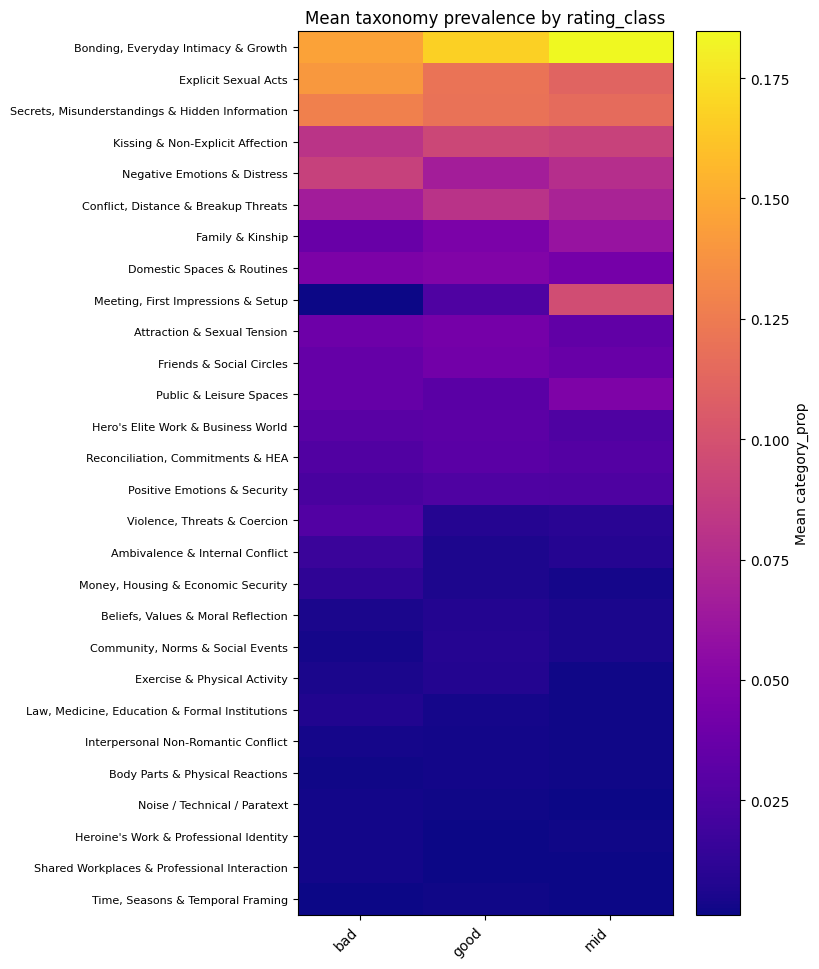

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/figures/heatmap_taxonomy_means_by_class.png
✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/tables/taxonomy_mean_prevalence_by_class.csv


In [7]:
# mean prevalence per class
mean_by_class = book_long.groupby(["taxonomy_main_id", "taxonomy_main_name", "rating_class"])["category_prop"].mean().reset_index()

# pivot for heatmap
heat = mean_by_class.pivot_table(index="taxonomy_main_name", columns="rating_class", values="category_prop", aggfunc="mean").fillna(0)

# sort by overall mean
heat["__overall__"] = heat.mean(axis=1)
heat = heat.sort_values("__overall__", ascending=False).drop(columns="__overall__")

# plot heatmap with a more contrast color palette (e.g., 'viridis' or 'plasma')
plt.figure(figsize=(8, max(6, 0.35 * len(heat))))
plt.imshow(heat.values, aspect="auto", cmap="plasma")
plt.yticks(range(len(heat.index)), heat.index, fontsize=8)
plt.xticks(range(len(heat.columns)), heat.columns, rotation=45, ha="right")
plt.colorbar(label="Mean category_prop")
plt.title("Mean taxonomy prevalence by rating_class")
plt.tight_layout()

fig_path = FIG_DIR / "heatmap_taxonomy_means_by_class.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved:", fig_path)

heat.to_csv(TABLE_DIR / "taxonomy_mean_prevalence_by_class.csv")
print("✓ Saved:", TABLE_DIR / "taxonomy_mean_prevalence_by_class.csv")

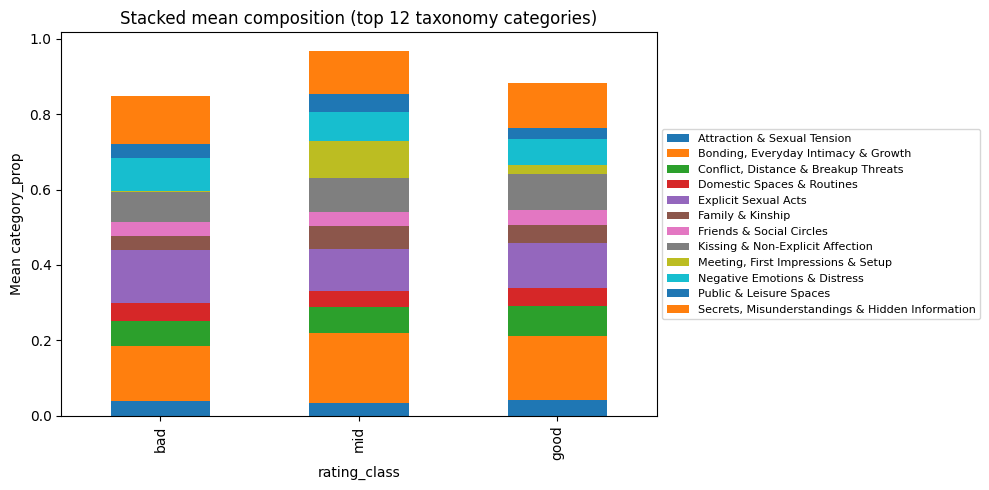

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/figures/stackedbar_top_taxonomy_mean_composition.png


In [8]:
top_k = 12

overall_mean = book_long.groupby(["taxonomy_main_name"])["category_prop"].mean().sort_values(ascending=False)
top_names = overall_mean.head(top_k).index.tolist()

stack_data = (
    book_long[book_long["taxonomy_main_name"].isin(top_names)]
    .groupby(["rating_class", "taxonomy_main_name"])["category_prop"]
    .mean()
    .unstack("taxonomy_main_name")
    .fillna(0)
)

# ensure class order
class_order = [c for c in ["bad", "mid", "good"] if c in stack_data.index]
stack_data = stack_data.loc[class_order]

ax = stack_data.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_ylabel("Mean category_prop")
ax.set_title(f"Stacked mean composition (top {top_k} taxonomy categories)")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()

fig_path = FIG_DIR / "stackedbar_top_taxonomy_mean_composition.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved:", fig_path)


,taxonomy_main_name,mean_diff_good_minus_bad
0,"Meeting, First Impressions & Setup",0.024788
1,"Bonding, Everyday Intimacy & Growth",0.021709
2,"Conflict, Distance & Breakup Threats",0.013869
3,Kissing & Non-Explicit Affection,0.012578
4,Family & Kinship,0.008522
5,Friends & Social Circles,0.005336
6,"Community, Norms & Social Events",0.004720
7,"Reconciliation, Commitments & HEA",0.004546
8,Attraction & Sexual Tension,0.003559
9,"Beliefs, Values & Moral Reflection",0.003065


✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/tables/taxonomy_mean_diff_good_minus_bad.csv


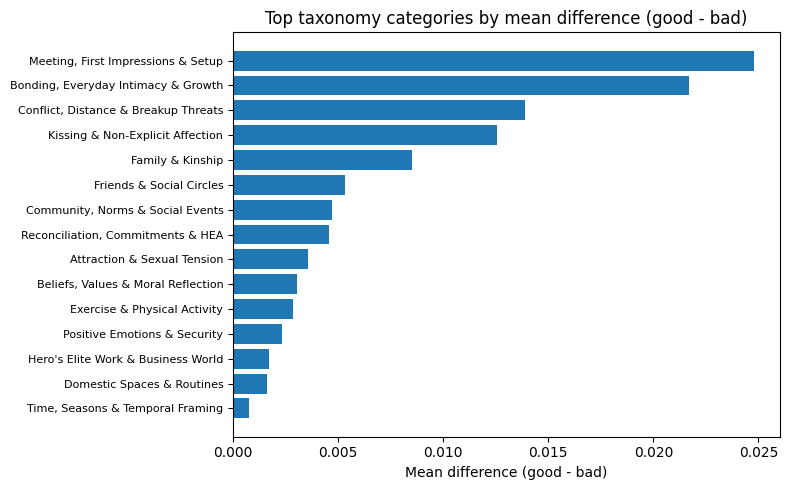

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/figures/top_taxonomy_mean_diff_good_bad.png


In [9]:
# Good - Bad mean difference (descriptive)
if "good" in heat.columns and "bad" in heat.columns:
    diff = (heat["good"] - heat["bad"]).sort_values(ascending=False)
    diff_df = diff.rename("mean_diff_good_minus_bad").reset_index().rename(columns={"taxonomy_main_name":"taxonomy_main_name"})

    display(diff_df.head(20))
    diff_df.to_csv(TABLE_DIR / "taxonomy_mean_diff_good_minus_bad.csv", index=False)
    print("✓ Saved:", TABLE_DIR / "taxonomy_mean_diff_good_minus_bad.csv")

    # plot top deltas
    top_plot = diff.head(15)
    plt.figure(figsize=(8, 5))
    plt.barh(range(len(top_plot)), top_plot.values)
    plt.yticks(range(len(top_plot)), top_plot.index, fontsize=8)
    plt.gca().invert_yaxis()
    plt.xlabel("Mean difference (good - bad)")
    plt.title("Top taxonomy categories by mean difference (good - bad)")
    plt.tight_layout()

    fig_path = FIG_DIR / "top_taxonomy_mean_diff_good_bad.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Saved:", fig_path)

else:
    print("⚠ 'good' and/or 'bad' not found among rating_class columns:", list(heat.columns))


## Statistical Testing: Category-Level Comparisons

Now we perform formal statistical tests to identify which taxonomy categories differ significantly between rating classes.


In [10]:
# Clean analytical subset
analysis_df = book_long.copy()

# Remove noise categories and missing values
analysis_df = analysis_df[
    (analysis_df["unmapped_topic_mass"] == 0) &
    (analysis_df["category_prop"].notna())
]

print(f"Analysis dataset shape: {analysis_df.shape}")
print(f"Unique books: {analysis_df['book_id'].nunique()}")
print(f"Unique categories: {analysis_df['taxonomy_main_name'].nunique()}")
print(f"Rating classes: {sorted(analysis_df['rating_class'].dropna().unique())}")


Analysis dataset shape: (2215, 22)
Unique books: 92
Unique categories: 28
Rating classes: ['bad', 'good', 'mid']


In [11]:
# Category-level statistical tests: Mann-Whitney U + Cliff's delta
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import seaborn as sns

def cliffs_delta(x, y):
    """Calculate Cliff's delta effect size."""
    x = np.asarray(x)
    y = np.asarray(y)
    gt = sum(xi > yj for xi in x for yj in y)
    lt = sum(xi < yj for xi in x for yj in y)
    return (gt - lt) / (len(x) * len(y))

# Perform tests for each category
mw_rows = []
for cat, g in analysis_df.groupby("taxonomy_main_name"):
    classes = g["rating_class"].dropna().unique()
    if len(classes) < 2:
        continue
    
    # Use the two most common classes if more than 2
    if len(classes) > 2:
        class_counts = g["rating_class"].value_counts()
        classes = class_counts.head(2).index.tolist()
    
    g1 = g[g["rating_class"] == classes[0]]["category_prop"]
    g2 = g[g["rating_class"] == classes[1]]["category_prop"]
    
    if g1.nunique() < 2 or g2.nunique() < 2:
        continue
    
    # Mann-Whitney U test
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    
    # Cliff's delta
    d = cliffs_delta(g1.values, g2.values)
    
    mw_rows.append({
        "taxonomy_main_name": cat,
        "taxonomy_main_group": g["taxonomy_main_group"].iloc[0],
        "class_a": classes[0],
        "class_b": classes[1],
        "median_a": g1.median(),
        "median_b": g2.median(),
        "mean_a": g1.mean(),
        "mean_b": g2.mean(),
        "n_a": len(g1),
        "n_b": len(g2),
        "p": p,
        "cliffs_delta": d
    })

mw_df = pd.DataFrame(mw_rows)

# FDR correction
mw_df["p_adj"] = multipletests(mw_df["p"], method="fdr_bh")[1]

# Sort by adjusted p-value
mw_df = mw_df.sort_values("p_adj")

print(f"Tested {len(mw_df)} categories")
print(f"Significant at p_adj < 0.05: {(mw_df['p_adj'] < 0.05).sum()}")
print(f"Significant at p_adj < 0.01: {(mw_df['p_adj'] < 0.01).sum()}")

display(mw_df.head(15))

# Save results
mw_df.to_csv(TABLE_DIR / "category_mannwhitney_results.csv", index=False)
mw_df.to_parquet(TABLE_DIR / "category_mannwhitney_results.parquet", index=False)
print(f"\n✓ Saved: {TABLE_DIR / 'category_mannwhitney_results.csv'}")

Tested 28 categories
Significant at p_adj < 0.05: 0
Significant at p_adj < 0.01: 0


,taxonomy_main_name,taxonomy_main_group,class_a,class_b,median_a,median_b,mean_a,mean_b,n_a,n_b,p,cliffs_delta,p_adj
5,"Community, Norms & Social Events",Social World Outside Couple,mid,good,0.002120,0.004838,0.005423,0.008507,29,27,0.063897,-0.289911,0.596376
6,"Conflict, Distance & Breakup Threats",Relationship Trajectory (Main Couple),mid,good,0.047933,0.062183,0.070187,0.080105,32,30,0.061988,-0.277083,0.596376
16,"Law, Medicine, Education & Formal Institutions","Work, Wealth, Status & Institutions",mid,good,0.001630,0.002701,0.002067,0.003605,24,20,0.049055,-0.350000,0.596376
13,Heroine's Work & Professional Identity,"Work, Wealth, Status & Institutions",mid,bad,0.001207,0.002317,0.002253,0.003032,30,23,0.086556,-0.278261,0.605895
3,Body Parts & Physical Reactions,Embodied & Sensory Experience,mid,good,0.001645,0.002232,0.001974,0.002735,28,25,0.146468,-0.234286,0.780740
24,"Secrets, Misunderstandings & Hidden Information",Relationship Trajectory (Main Couple),mid,good,0.107215,0.110935,0.115502,0.119830,32,30,0.320683,-0.147917,0.780740
7,Domestic Spaces & Routines,"Spaces, Time, Activities & Objects",mid,good,0.044619,0.047876,0.043279,0.048610,32,30,0.236718,-0.176042,0.780740
20,Noise / Technical / Paratext,Special,mid,bad,0.001241,0.001514,0.001885,0.002658,25,21,0.331887,-0.169524,0.780740
19,Negative Emotions & Distress,"Emotions, Cognition & Inner Life",mid,good,0.066649,0.061392,0.077372,0.066674,32,30,0.187828,0.195833,0.780740
17,"Meeting, First Impressions & Setup",Relationship Trajectory (Main Couple),mid,good,0.096794,0.025987,0.096794,0.025987,2,2,0.333333,1.000000,0.780740



✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/tables/category_mannwhitney_results.csv


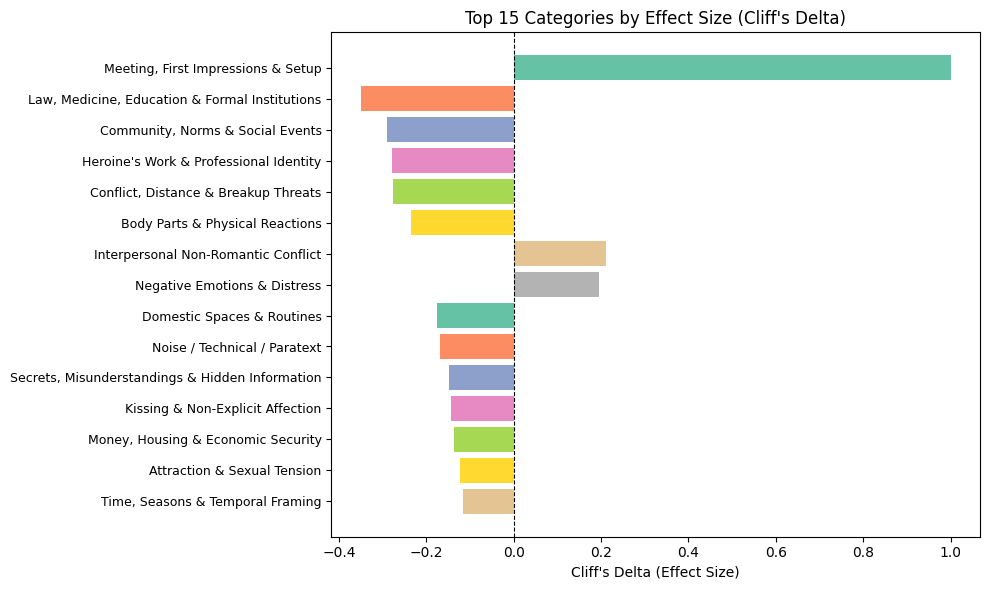

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/figures/category_effect_size_cliffs_delta.png


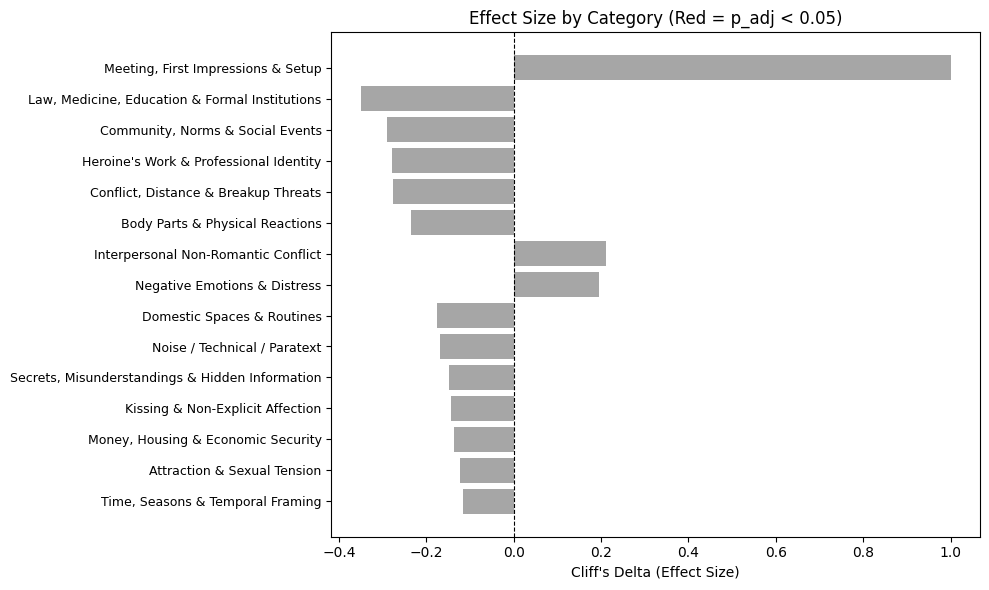

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/figures/category_effect_size_significant.png


In [12]:
# Effect size visualization: Cliff's delta bar plot
top_effects = mw_df.sort_values("cliffs_delta", key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = [sns.color_palette("Set2")[i % len(sns.color_palette("Set2"))] 
          for i in range(len(top_effects))]
bars = plt.barh(range(len(top_effects)), top_effects["cliffs_delta"], color=colors)
plt.yticks(range(len(top_effects)), top_effects["taxonomy_main_name"], fontsize=9)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Cliff's Delta (Effect Size)")
plt.title("Top 15 Categories by Effect Size (Cliff's Delta)")
plt.gca().invert_yaxis()
plt.tight_layout()

fig_path = FIG_DIR / "category_effect_size_cliffs_delta.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {fig_path}")

# Color by significance
plt.figure(figsize=(10, 6))
sig_mask = top_effects["p_adj"] < 0.05
colors = ["red" if sig else "gray" for sig in sig_mask]
bars = plt.barh(range(len(top_effects)), top_effects["cliffs_delta"], color=colors, alpha=0.7)
plt.yticks(range(len(top_effects)), top_effects["taxonomy_main_name"], fontsize=9)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Cliff's Delta (Effect Size)")
plt.title("Effect Size by Category (Red = p_adj < 0.05)")
plt.gca().invert_yaxis()
plt.tight_layout()

fig_path = FIG_DIR / "category_effect_size_significant.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {fig_path}")


In [13]:
# Violin plots for top significant categories
top_cats = mw_df[mw_df["p_adj"] < 0.05].sort_values("p_adj").head(6)["taxonomy_main_name"]

if len(top_cats) > 0:
    plot_df = analysis_df[analysis_df["taxonomy_main_name"].isin(top_cats)]
    
    plt.figure(figsize=(12, 8))
    sns.violinplot(
        data=plot_df,
        x="taxonomy_main_name",
        y="category_prop",
        hue="rating_class",
        split=True,
        inner="box"
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Category Proportion")
    plt.xlabel("Taxonomy Category")
    plt.title("Distribution of Category Proportions by Rating Class\n(Top 6 Significant Categories)")
    plt.legend(title="Rating Class")
    plt.tight_layout()
    
    fig_path = FIG_DIR / "violin_top_significant_categories.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved: {fig_path}")
else:
    print("No significant categories found for violin plot")


No significant categories found for violin plot


## Group-Level Patterns (Theory-Aligned)

To connect results back to theory, we aggregate category proportions at the level of taxonomy main groups (e.g., Sexuality, Embodied Experience).

For each book, group-level proportions represent the total share of text assigned to that thematic domain.

These group-level distributions are then compared across rating classes using the same non-parametric framework.


In [26]:
# Group-level aggregation
group_df = (
    analysis_df
    .groupby(["book_id", "rating_class", "taxonomy_main_group"], as_index=False)
    .agg(group_prop=("category_prop", "sum"))
)

print(f"Group-level data shape: {group_df.shape}")
print(f"Unique groups: {group_df['taxonomy_main_group'].nunique()}")
display(group_df.head())

# Group-level statistical tests
group_rows = []
for grp, g in group_df.groupby("taxonomy_main_group"):
    classes = g["rating_class"].dropna().unique()
    if len(classes) < 2:
        continue
    
    if len(classes) > 2:
        class_counts = g["rating_class"].value_counts()
        classes = class_counts.head(2).index.tolist()
    
    g1 = g[g["rating_class"] == classes[0]]["group_prop"]
    g2 = g[g["rating_class"] == classes[1]]["group_prop"]
    
    if g1.nunique() < 2 or g2.nunique() < 2:
        continue
    
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    d = cliffs_delta(g1.values, g2.values)
    
    group_rows.append({
        "taxonomy_main_group": grp,
        "class_a": classes[0],
        "class_b": classes[1],
        "median_a": g1.median(),
        "median_b": g2.median(),
        "mean_a": g1.mean(),
        "mean_b": g2.mean(),
        "n_a": len(g1),
        "n_b": len(g2),
        "p": p,
        "cliffs_delta": d
    })

group_test_df = pd.DataFrame(group_rows)
group_test_df["p_adj"] = multipletests(group_test_df["p"], method="fdr_bh")[1]
group_test_df = group_test_df.sort_values("p_adj")

print(f"\nTested {len(group_test_df)} taxonomy groups")
print(f"Significant at p_adj < 0.05: {(group_test_df['p_adj'] < 0.05).sum()}")

display(group_test_df)

# Save results
group_test_df.to_csv(TABLE_DIR / "group_mannwhitney_results.csv", index=False)
group_test_df.to_parquet(TABLE_DIR / "group_mannwhitney_results.parquet", index=False)
print(f"\n✓ Saved: {TABLE_DIR / 'group_mannwhitney_results.csv'}")


Group-level data shape: (793, 4)
Unique groups: 9


,book_id,rating_class,taxonomy_main_group,group_prop
0,15197.0,good,"Conflict, Risk & Harm",0.013564
1,15197.0,good,Embodied & Sensory Experience,0.003768
2,15197.0,good,"Emotions, Cognition & Inner Life",0.097212
3,15197.0,good,Relationship Trajectory (Main Couple),0.333082
4,15197.0,good,"Sexuality, Attraction & Intimacy",0.311982



Tested 9 taxonomy groups
Significant at p_adj < 0.05: 0


,taxonomy_main_group,class_a,class_b,median_a,median_b,mean_a,mean_b,n_a,n_b,p,cliffs_delta,p_adj
1,Embodied & Sensory Experience,mid,good,0.002228,0.003611,0.002927,0.009356,32,26,0.012638,-0.384615,0.113742
0,"Conflict, Risk & Harm",mid,good,0.007620,0.006720,0.011392,0.010789,32,30,0.849184,-0.029167,0.938248
2,"Emotions, Cognition & Inner Life",mid,good,0.107834,0.100973,0.115715,0.105079,32,30,0.521582,0.095833,0.938248
3,Relationship Trajectory (Main Couple),mid,good,0.405010,0.399223,0.404752,0.399761,32,30,0.938248,0.012500,0.938248
4,"Sexuality, Attraction & Intimacy",mid,good,0.222004,0.243447,0.235456,0.256947,32,30,0.327595,-0.145833,0.938248
5,Social World Outside Couple,mid,good,0.070953,0.082632,0.102554,0.095081,32,30,0.772764,-0.043750,0.938248
6,"Spaces, Time, Activities & Objects",mid,good,0.078077,0.081046,0.092044,0.081161,32,30,0.568353,-0.085417,0.938248
7,Special,mid,bad,0.001241,0.001514,0.001885,0.002658,25,21,0.331887,-0.169524,0.938248
8,"Work, Wealth, Status & Institutions",mid,good,0.025689,0.029310,0.033687,0.041355,32,30,0.762007,-0.045833,0.938248



✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/tables/group_mannwhitney_results.csv


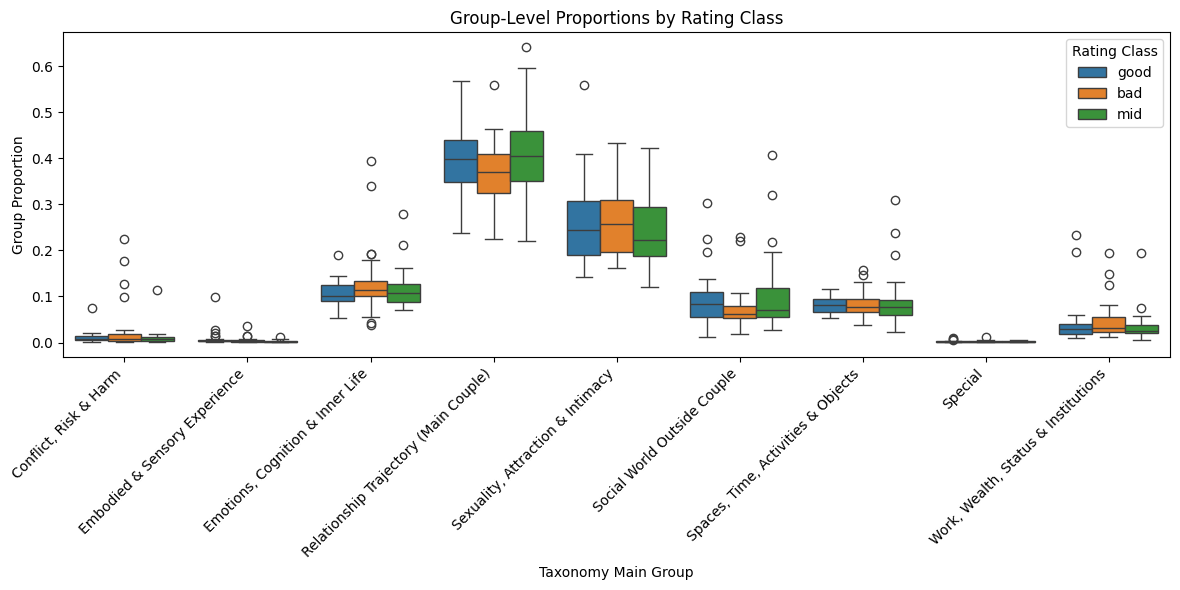

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/figures/boxplot_group_proportions_by_class.png


In [27]:
# Group-level boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=group_df,
    x="taxonomy_main_group",
    y="group_prop",
    hue="rating_class"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Group Proportion")
plt.xlabel("Taxonomy Main Group")
plt.title("Group-Level Proportions by Rating Class")
plt.legend(title="Rating Class")
plt.tight_layout()

fig_path = FIG_DIR / "boxplot_group_proportions_by_class.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {fig_path}")


## Correlation Structure Among Categories

Rather than summarizing themes via indices, we examine how categories co-occur empirically.

Using Spearman correlations between category proportions:

- We identify clusters of themes that tend to appear together
- We assess whether categories within the same taxonomy group form coherent empirical groupings

These correlations provide insight into the latent structure of the narrative space without imposing predefined composites.


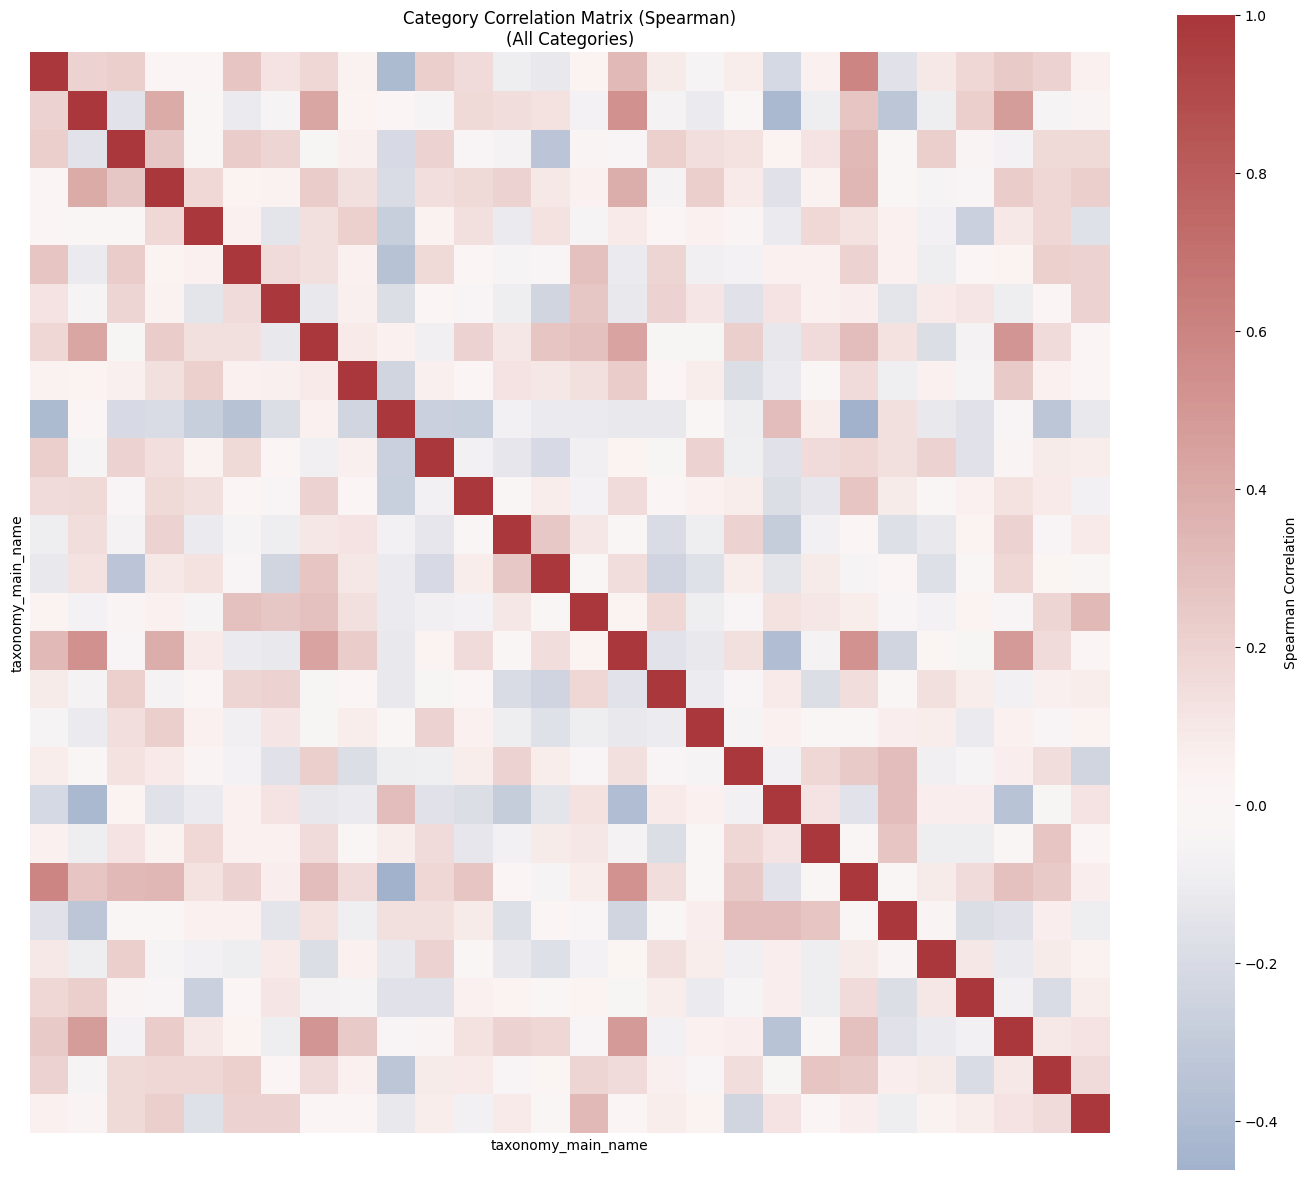

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/figures/correlation_matrix_all_categories.png
✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/tables/category_correlation_matrix.csv


In [16]:
# Global correlation matrix
wide_cat = analysis_df.pivot_table(
    index="book_id",
    columns="taxonomy_main_name",
    values="category_prop",
    fill_value=0.0
)

corr_global = wide_cat.corr(method="spearman")

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_global,
    cmap="vlag",
    center=0,
    square=True,
    fmt=".2f",
    cbar_kws={"label": "Spearman Correlation"},
    xticklabels=False,
    yticklabels=False
)
plt.title("Category Correlation Matrix (Spearman)\n(All Categories)")
plt.tight_layout()

fig_path = FIG_DIR / "correlation_matrix_all_categories.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {fig_path}")

# Save correlation matrix
corr_global.to_csv(TABLE_DIR / "category_correlation_matrix.csv")
corr_global.to_parquet(TABLE_DIR / "category_correlation_matrix.parquet")
print(f"✓ Saved: {TABLE_DIR / 'category_correlation_matrix.csv'}")


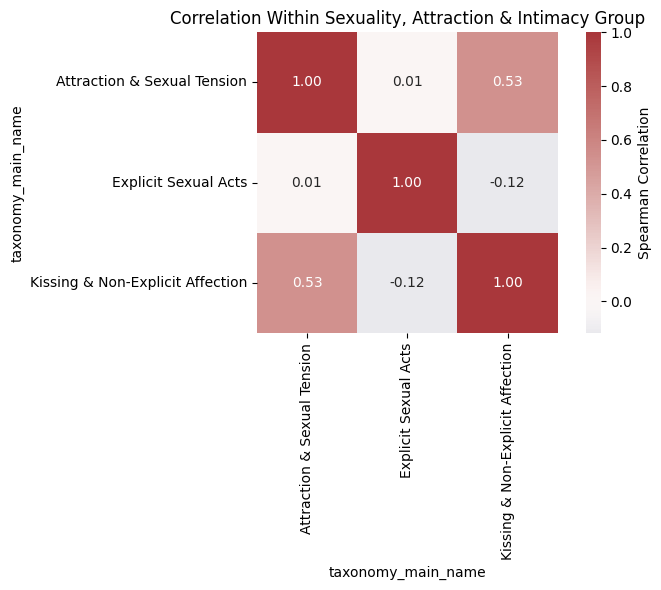

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/figures/correlation_within_sexuality_group.png


In [17]:
# Within-group correlation: Sexuality group example
sexual_df = analysis_df[
    analysis_df["taxonomy_main_group"] == "Sexuality, Attraction & Intimacy"
]

if len(sexual_df) > 0:
    wide_sexual = sexual_df.pivot_table(
        index="book_id",
        columns="taxonomy_main_name",
        values="category_prop",
        fill_value=0.0
    )
    
    if wide_sexual.shape[1] > 1:
        corr_sexual = wide_sexual.corr(method="spearman")
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            corr_sexual,
            cmap="vlag",
            center=0,
            square=True,
            annot=True,
            fmt=".2f",
            cbar_kws={"label": "Spearman Correlation"}
        )
        plt.title("Correlation Within Sexuality, Attraction & Intimacy Group")
        plt.tight_layout()
        
        fig_path = FIG_DIR / "correlation_within_sexuality_group.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"✓ Saved: {fig_path}")
    else:
        print("Not enough categories in Sexuality group for correlation")
else:
    print("No data found for Sexuality group")


## Mapping Results to Radway Narrative Phases

Finally, we interpret category-level results through the lens of Radway's narrative phases.

Using the topic lookup table:

- Each taxonomy category is linked to one or more Radway phases
- Categories showing strong associations with rating outcomes are mapped to their dominant narrative phases

This allows us to ask:

- Which narrative phases are overrepresented in higher-rated books?
- Are certain phases associated with negative or positive reception?

Importantly, Radway phases are used **only for interpretation**, not as constructed indices.


In [18]:
# Load topic lookup
topic_lookup = pd.read_parquet(EDA_DIR_NB1 / "topic_lookup.parquet")

# Build category → Radway phase map
# Use the most frequent Radway phase for each taxonomy category
radway_map = (
    topic_lookup
    .groupby("taxonomy_main_name")["radway_phase_name"]
    .agg(lambda x: x.value_counts().idxmax() if len(x.value_counts()) > 0 else None)
    .reset_index()
    .rename(columns={"radway_phase_name": "radway_phase_name"})
)

print(f"Mapped {len(radway_map)} categories to Radway phases")
display(radway_map.head(10))

# Attach Radway phases to statistical results
mw_with_radway = mw_df.merge(
    radway_map,
    on="taxonomy_main_name",
    how="left"
)

mw_with_radway = mw_with_radway.sort_values("p_adj")

print(f"\nCategories with Radway mapping: {mw_with_radway['radway_phase_name'].notna().sum()}")
display(mw_with_radway.head(15))

# Save
mw_with_radway.to_csv(TABLE_DIR / "category_results_with_radway.csv", index=False)
mw_with_radway.to_parquet(TABLE_DIR / "category_results_with_radway.parquet", index=False)
print(f"\n✓ Saved: {TABLE_DIR / 'category_results_with_radway.csv'}")


Mapped 28 categories to Radway phases


,taxonomy_main_name,radway_phase_name
0,Ambivalence & Internal Conflict,Initial Conflict & Isolation
1,Attraction & Sexual Tension,Initial Conflict & Isolation
2,"Beliefs, Values & Moral Reflection",Not a narrative function
3,Body Parts & Physical Reactions,Not a narrative function
4,"Bonding, Everyday Intimacy & Growth",Turning Point & Recognition
5,"Community, Norms & Social Events",Not a narrative function
6,"Conflict, Distance & Breakup Threats",Initial Conflict & Isolation
7,Domestic Spaces & Routines,Not a narrative function
8,Exercise & Physical Activity,Not a narrative function
9,Explicit Sexual Acts,Commitment & Restoration



Categories with Radway mapping: 28


,taxonomy_main_name,taxonomy_main_group,class_a,class_b,median_a,median_b,mean_a,mean_b,n_a,n_b,p,cliffs_delta,p_adj,radway_phase_name
0,"Community, Norms & Social Events",Social World Outside Couple,mid,good,0.002120,0.004838,0.005423,0.008507,29,27,0.063897,-0.289911,0.596376,Not a narrative function
1,"Conflict, Distance & Breakup Threats",Relationship Trajectory (Main Couple),mid,good,0.047933,0.062183,0.070187,0.080105,32,30,0.061988,-0.277083,0.596376,Initial Conflict & Isolation
2,"Law, Medicine, Education & Formal Institutions","Work, Wealth, Status & Institutions",mid,good,0.001630,0.002701,0.002067,0.003605,24,20,0.049055,-0.350000,0.596376,Not a narrative function
3,Heroine's Work & Professional Identity,"Work, Wealth, Status & Institutions",mid,bad,0.001207,0.002317,0.002253,0.003032,30,23,0.086556,-0.278261,0.605895,Not a narrative function
4,Body Parts & Physical Reactions,Embodied & Sensory Experience,mid,good,0.001645,0.002232,0.001974,0.002735,28,25,0.146468,-0.234286,0.780740,Not a narrative function
5,"Secrets, Misunderstandings & Hidden Information",Relationship Trajectory (Main Couple),mid,good,0.107215,0.110935,0.115502,0.119830,32,30,0.320683,-0.147917,0.780740,Initial Conflict & Isolation
6,Domestic Spaces & Routines,"Spaces, Time, Activities & Objects",mid,good,0.044619,0.047876,0.043279,0.048610,32,30,0.236718,-0.176042,0.780740,Not a narrative function
7,Noise / Technical / Paratext,Special,mid,bad,0.001241,0.001514,0.001885,0.002658,25,21,0.331887,-0.169524,0.780740,Not a narrative function
8,Negative Emotions & Distress,"Emotions, Cognition & Inner Life",mid,good,0.066649,0.061392,0.077372,0.066674,32,30,0.187828,0.195833,0.780740,Initial Conflict & Isolation
9,"Meeting, First Impressions & Setup",Relationship Trajectory (Main Couple),mid,good,0.096794,0.025987,0.096794,0.025987,2,2,0.333333,1.000000,0.780740,Initial Conflict & Isolation



✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/tables/category_results_with_radway.csv


In [19]:
# Summarize significant categories by Radway phase
radway_summary = (
    mw_with_radway[mw_with_radway["p_adj"] < 0.05]
    .groupby("radway_phase_name")
    .agg({
        "taxonomy_main_name": "count",
        "cliffs_delta": ["mean", "std"]
    })
    .reset_index()
)

radway_summary.columns = ["radway_phase_name", "n_significant_categories", "mean_cliffs_delta", "std_cliffs_delta"]
radway_summary = radway_summary.sort_values("n_significant_categories", ascending=False)

print("Radway phases with significant category differences:")
display(radway_summary)

# Visualization
if len(radway_summary) > 0:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=radway_summary,
        x="radway_phase_name",
        y="n_significant_categories"
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Number of Significant Categories")
    plt.xlabel("Radway Narrative Phase")
    plt.title("Radway Phases Associated with Significant Category Differences\n(p_adj < 0.05)")
    plt.tight_layout()
    
    fig_path = FIG_DIR / "radway_phase_signal_strength.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved: {fig_path}")
    
    # Save summary
    radway_summary.to_csv(TABLE_DIR / "radway_phase_summary.csv", index=False)
    radway_summary.to_parquet(TABLE_DIR / "radway_phase_summary.parquet", index=False)
    print(f"✓ Saved: {TABLE_DIR / 'radway_phase_summary.csv'}")
else:
    print("No significant categories found for Radway phase summary")


Radway phases with significant category differences:


,radway_phase_name,n_significant_categories,mean_cliffs_delta,std_cliffs_delta


No significant categories found for Radway phase summary


## Correlations & multicollinearity diagnostics

Correlation matrices are only diagnostic (especially with compositional data), but still useful:

- Correlation heatmap among indices

- Correlation heatmap among top taxonomy categories


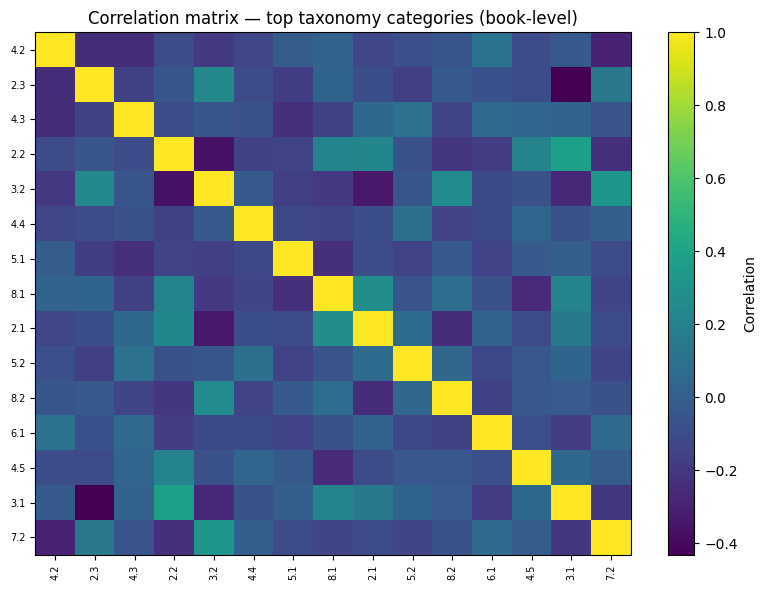

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/figures/corr_top_taxonomy_categories.png
✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/tables/corr_top_taxonomy_categories.csv


In [20]:
# pick top 15 taxonomy cols by global mean
means = X.mean(axis=0).sort_values(ascending=False)
top_tax_cols = means.head(15).index.tolist()
corr_tax = book_wide[top_tax_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(corr_tax.values, aspect="auto")
plt.xticks(range(len(corr_tax.columns)), corr_tax.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr_tax.index)), corr_tax.index, fontsize=7)
plt.colorbar(label="Correlation")
plt.title("Correlation matrix — top taxonomy categories (book-level)")
plt.tight_layout()

fig_path = FIG_DIR / "corr_top_taxonomy_categories.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved:", fig_path)

corr_tax.to_csv(TABLE_DIR / "corr_top_taxonomy_categories.csv")
print("✓ Saved:", TABLE_DIR / "corr_top_taxonomy_categories.csv")


## Unsupervised structure: PCA + optional UMAP

We visualize whether rating classes form natural clusters based on taxonomy composition.

PCA always runs. UMAP runs only if the `umap-learn` package is installed.


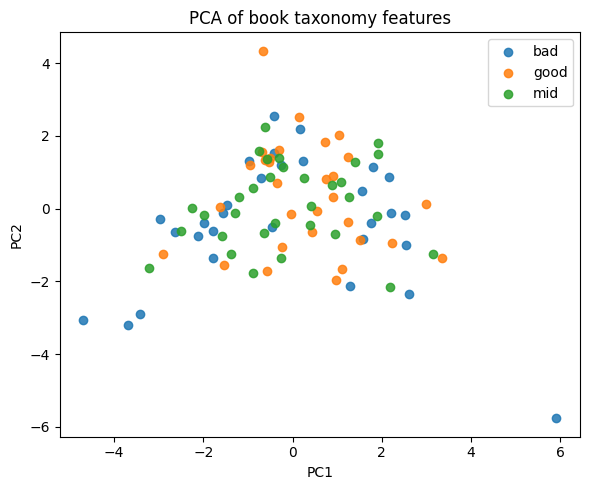

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/figures/pca_books_taxonomy.png
✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/tables/pca_explained_variance.csv


,component,explained_variance_ratio
0,PC1,0.114811
1,PC2,0.083049


In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Defensive merge: Use book_wide if rating_class already present, 
# else try to merge from book_long, book_meta, or book_df if possible.
if "rating_class" in book_wide.columns:
    wide = book_wide.copy()
else:
    # Fallback: try to get rating_class from book_long, book_meta, or book_df
    # book_long is the most likely source since it contains rating_class
    possible_sources = []
    for dfname in ["book_long", "book_meta", "book_df"]:
        if dfname in globals():
            possible_sources.append(globals()[dfname])
    found_match = False
    for src in possible_sources:
        if "book_id" in src.columns and "rating_class" in src.columns:
            wide = book_wide.merge(src[["book_id", "rating_class"]].drop_duplicates("book_id"), on="book_id", how="left")
            found_match = True
            break
    if not found_match:
        raise NameError(
            "No DataFrame named 'book_long', 'book_meta', or 'book_df' with 'book_id' and 'rating_class' found in the current namespace."
        )

# feature matrix (exclude noise if present)
feat_cols = [c for c in taxonomy_cols if c != "noise"]
Xmat = wide[feat_cols].fillna(0).values

# Standardize for PCA
Xstd = StandardScaler().fit_transform(Xmat)

pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xstd)

plt.figure(figsize=(6, 5))
for cls in sorted(wide["rating_class"].dropna().unique()):
    mask = (wide["rating_class"] == cls).values
    plt.scatter(Z[mask, 0], Z[mask, 1], label=str(cls), alpha=0.85)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of book taxonomy features")
plt.legend()
plt.tight_layout()

fig_path = FIG_DIR / "pca_books_taxonomy.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved:", fig_path)

# Save explained variance
ev = pd.DataFrame({"component": ["PC1", "PC2"], "explained_variance_ratio": pca.explained_variance_ratio_})
ev.to_csv(TABLE_DIR / "pca_explained_variance.csv", index=False)
print("✓ Saved:", TABLE_DIR / "pca_explained_variance.csv")
display(ev)


/home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/venv/lib/python3.12/site-packages/umap/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


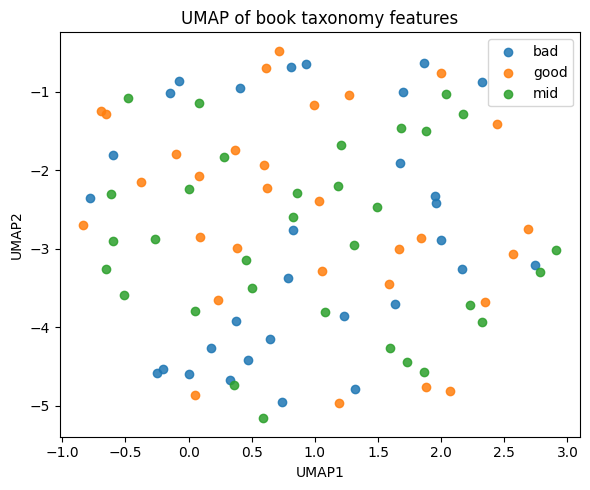

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/figures/umap_books_taxonomy.png


In [22]:
try:
    import umap

    reducer = umap.UMAP(random_state=0, n_neighbors=15, min_dist=0.1)
    U = reducer.fit_transform(Xstd)

    plt.figure(figsize=(6, 5))
    for cls in sorted(wide["rating_class"].dropna().unique()):
        mask = (wide["rating_class"] == cls).values
        plt.scatter(U[mask, 0], U[mask, 1], label=str(cls), alpha=0.85)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("UMAP of book taxonomy features")
    plt.legend()
    plt.tight_layout()

    fig_path = FIG_DIR / "umap_books_taxonomy.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Saved:", fig_path)

except Exception as e:
    print("⚠ UMAP skipped (umap-learn not installed or failed):", e)


## Optional: Radway rollups at book level

If we have `book_topic_probs.parquet` and `topic_lookup.parquet` with matching book_id types,
we can aggregate topic probabilities into Radway function and phase shares per book.

If IDs don't align, we still export a coverage diagnostic and defer full Radway analyses.


In [23]:
book_topic_probs_path = paths["book_topic_probs"]
topic_lookup_path     = paths["NB1 topic_lookup"]

if book_topic_probs_path.exists() and topic_lookup_path.exists():
    btp = pd.read_parquet(book_topic_probs_path)
    tl  = pd.read_parquet(topic_lookup_path)

    print("book_topic_probs shape:", btp.shape)
    print("topic_lookup shape:", tl.shape)
    print("book_topic_probs book_id dtype:", btp["book_id"].dtype if "book_id" in btp.columns else "MISSING")
    print("wide book_id dtype:", wide["book_id"].dtype)

    # join coverage check
    overlap = set(btp["book_id"].unique()).intersection(set(wide["book_id"].unique()))
    coverage = {
        "btp_unique_books": int(btp["book_id"].nunique()),
        "wide_unique_books": int(wide["book_id"].nunique()),
        "overlap_books": int(len(overlap)),
        "overlap_share_of_btp": float(len(overlap) / max(1, btp["book_id"].nunique())),
        "overlap_share_of_wide": float(len(overlap) / max(1, wide["book_id"].nunique())),
    }
    coverage_df = pd.DataFrame([coverage])
    display(coverage_df)
    coverage_df.to_csv(TABLE_DIR / "radway_join_coverage.csv", index=False)
    print("✓ Saved:", TABLE_DIR / "radway_join_coverage.csv")

    # Only proceed if overlap is reasonably high
    if coverage["overlap_books"] > 0:
        btp2 = btp.merge(tl[["topic_id", "radway_main_id", "radway_phase_name", "radway_is_none"]], on="topic_id", how="left")

        # rollup: radway phase share (excluding radway none if you want)
        btp2["prob"] = btp2["prob"].astype(float)
        phase_roll = (
            btp2[btp2["radway_is_none"] == False]
            .groupby(["book_id", "radway_phase_name"])["prob"]
            .sum()
            .reset_index()
        )

        phase_wide = phase_roll.pivot_table(index="book_id", columns="radway_phase_name", values="prob", aggfunc="sum").fillna(0).reset_index()
        # merge rating_class
        phase_wide = phase_wide.merge(book_class, on="book_id", how="left")

        phase_wide.to_parquet(TABLE_DIR / "radway_phase_book_wide.parquet", index=False)
        print("✓ Saved:", TABLE_DIR / "radway_phase_book_wide.parquet")

        # Plot mean phase shares by class
        phase_cols = [c for c in phase_wide.columns if c not in {"book_id", "rating_class"}]
        mean_phase = phase_wide.groupby("rating_class")[phase_cols].mean()

        plt.figure(figsize=(7, 4))
        ax = mean_phase.plot(kind="bar", stacked=True, figsize=(8, 4))
        ax.set_ylabel("Mean Radway phase share (sum prob)")
        ax.set_title("Radway phase share by rating_class (if joinable)")
        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
        plt.tight_layout()

        fig_path = FIG_DIR / "radway_phase_share_by_class.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show()
        print("✓ Saved:", fig_path)

    else:
        print("⚠ No overlap between book_topic_probs book_id and wide book_id — Radway rollups deferred.")

else:
    print("⚠ Missing book_topic_probs or topic_lookup — Radway rollups skipped.")


book_topic_probs shape: (34592, 3)
topic_lookup shape: (368, 20)
book_topic_probs book_id dtype: object
wide book_id dtype: float64


,btp_unique_books,wide_unique_books,overlap_books,overlap_share_of_btp,overlap_share_of_wide
0,94,92,0,0.0,0.0


✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/tables/radway_join_coverage.csv
⚠ No overlap between book_topic_probs book_id and wide book_id — Radway rollups deferred.


## Chapter feasibility diagnostics (for Notebook 6)

We check chapter-level availability and diagnose ID alignment issues:

- How many unique books in chapter_topic_probs?

- Does book_id overlap with book-level numeric IDs?

- Is chapter_id numeric/sortable so tertile segmentation is feasible?


chapter_topic_probs shape: (1099584, 6)
Unique chapter books: 94
book_id dtype: object
chapter_id dtype: int64


,chapter_unique_books,wide_unique_books,overlap_books,overlap_share_of_chapter,overlap_share_of_wide
0,94,92,0,0.0,0.0


✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/tables/book_id_alignment_chapter_vs_bookfeatures.csv


,n_chapters
count,94.000000
mean,31.787234
std,15.281497
min,4.000000
25%,20.250000
50%,31.000000
75%,42.000000
max,73.000000


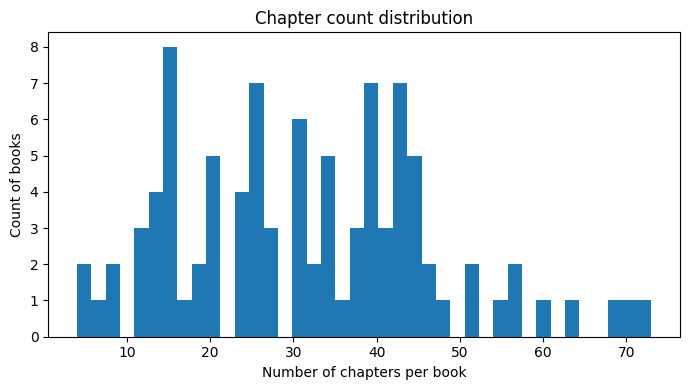

✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/figures/chapters_per_book_hist.png


In [24]:
chapter_path = paths["chapter_topic_probs"]

if chapter_path.exists():
    ch = pd.read_parquet(chapter_path)
    print("chapter_topic_probs shape:", ch.shape)
    print("Unique chapter books:", ch["book_id"].nunique())
    print("book_id dtype:", ch["book_id"].dtype)
    print("chapter_id dtype:", ch["chapter_id"].dtype)

    # overlap with wide book_id
    overlap = set(ch["book_id"].unique()).intersection(set(wide["book_id"].unique()))
    diag = {
        "chapter_unique_books": int(ch["book_id"].nunique()),
        "wide_unique_books": int(wide["book_id"].nunique()),
        "overlap_books": int(len(overlap)),
        "overlap_share_of_chapter": float(len(overlap) / max(1, ch["book_id"].nunique())),
        "overlap_share_of_wide": float(len(overlap) / max(1, wide["book_id"].nunique())),
    }
    diag_df = pd.DataFrame([diag])
    display(diag_df)

    diag_df.to_csv(TABLE_DIR / "book_id_alignment_chapter_vs_bookfeatures.csv", index=False)
    print("✓ Saved:", TABLE_DIR / "book_id_alignment_chapter_vs_bookfeatures.csv")

    # chapters per book distribution (based on unique chapter_id)
    chapters_per_book = ch.groupby("book_id")["chapter_id"].nunique().rename("n_chapters").reset_index()
    display(chapters_per_book.describe())

    plt.figure(figsize=(7, 4))
    plt.hist(chapters_per_book["n_chapters"].values, bins=40)
    plt.xlabel("Number of chapters per book")
    plt.ylabel("Count of books")
    plt.title("Chapter count distribution")
    plt.tight_layout()

    fig_path = FIG_DIR / "chapters_per_book_hist.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Saved:", fig_path)

else:
    print("⚠ chapter_topic_probs not found — skipping chapter diagnostics.")


## Export: single book-level dataset for Notebook 4/5

We create a single table:

- book_id, rating_class

- taxonomy proportions (wide)

- (optional) radway phase shares if joinable

**Note:** Indices are not included. Use category proportions directly for analysis.

In [25]:
# Base: taxonomy wide + rating_class
book_features = wide.copy()

# Note: Indices are not included in the export. Use category proportions directly.

# Optional: add radway phase shares if computed
radway_phase_path = TABLE_DIR / "radway_phase_book_wide.parquet"
if radway_phase_path.exists():
    phase_wide = pd.read_parquet(radway_phase_path)
    # avoid duplicating rating_class
    phase_cols = [c for c in phase_wide.columns if c not in {"rating_class"}]
    book_features = book_features.merge(phase_wide[phase_cols], on="book_id", how="left")

# Save
out_parquet = NB3_DIR / "book_features_for_stats.parquet"
out_csv     = NB3_DIR / "book_features_for_stats.csv"

book_features.to_parquet(out_parquet, index=False)
book_features.to_csv(out_csv, index=False)

print("✓ Saved:", out_parquet)
print("✓ Saved:", out_csv)

display(book_features.head())


✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/book_features_for_stats.parquet
✓ Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/notebook3_eda/book_features_for_stats.csv


,book_id,1.1,1.5,2.1,2.2,2.3,3.1,3.2,3.3,3.4,...,6.3,6.4,6.5,7.1,7.2,8.1,8.2,8.4,noise,rating_class
0,15197.0,0.003014,0.000754,0.042200,0.114544,0.155237,0.017332,0.070836,0.000754,0.008289,...,0.000000,0.000754,0.000000,0.005275,0.008289,0.072344,0.039940,0.003014,0.008289,good
1,21787.0,0.001091,0.001091,0.014177,0.056707,0.249727,0.010905,0.169029,0.000000,0.010905,...,0.000000,0.004362,0.001091,0.005453,0.003272,0.035987,0.033806,0.000000,0.004362,good
2,161913.0,0.002268,0.000567,0.035714,0.043651,0.105442,0.013605,0.111678,0.001701,0.006803,...,0.000000,0.000000,0.000000,0.000000,0.024376,0.017007,0.054422,0.000000,0.000000,bad
3,306364.0,0.002380,0.000000,0.117987,0.076165,0.033322,0.021761,0.043863,0.006460,0.004080,...,0.000340,0.002720,0.001700,0.001360,0.010201,0.040462,0.025502,0.001360,0.000680,mid
4,1756703.0,0.001409,0.000352,0.164553,0.065891,0.033474,0.023608,0.042283,0.004581,0.002819,...,0.001057,0.000352,0.003524,0.001409,0.073996,0.047216,0.006695,0.001409,0.000000,good
